<a href="https://colab.research.google.com/github/profession-ai-data-engineering-master/profession_ai_data_engineering_progetto6/blob/main/profession_ai_data_engineering_progetto6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-processing di un Dataset di Rilevazione del Tumore al Seno

**Dataset**: [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/tunguz/breast-cancer-wisconsin-diagnostic-data)

## Contesto del Progetto

Nel settore sanitario si utilizzano sempre più dati per prendere decisioni informate. Il presente progetto riguarda un dataset di rilevazione del tumore al seno, con l'obiettivo di creare un set di dati pulito e pronto per essere utilizzato nei modelli di machine learning. La pulizia e l'organizzazione dei dati sono fondamentali per migliorare la qualità e le performance dei modelli.

## Obiettivo del Progetto

L'obiettivo è ottenere un unico oggetto finale che racchiuda tutte le fasi di preprocessing applicabili a tutte le colonne del dataset, eccetto la colonna target. Ciò consente di avere un workflow strutturato e riutilizzabile per la preparazione dei dati prima dell'addestramento del modello. L'utilizzo di un unico oggetto facilita il tracciamento e la riproducibilità del processo di preprocessing.

## Valore Aggiunto

* Automazione e scalabilità: Le pipeline garantiscono un processo automatizzato e replicabile su nuovi dataset, riducendo i tempi di preparazione del dataset.
* Ottimizzazione della qualità dei dati: Grazie alla pulizia dei dati e alla gestione delle anomalie, la qualità del dataset sarà migliorata, portando a modelli più robusti.
* Personalizzazione delle tecniche di pre-processing: Le pipeline offrono flessibilità nell'applicazione di tecniche avanzate come l'analisi della skewness, la PCA (Principal Component Analysis) e la selezione delle variabili più informative.

## Descrizione delle Pipeline

### Pipeline 1: Pre-processing per Record con Target = 1

(Questa pipeline si concentra sui soli record in cui il target è pari a 1, ovvero i casi positivi di rilevazione del tumore. La pipeline include:)

1. Pulizia dei valori mancanti: La pulizia sarà distinta tra variabili asimmetriche e variabili simmetriche; per queste ultime si opterà per metodi di riempimento più standard.
2. Simmetrizzazione delle variabili asimmetriche: Per garantire una distribuzione più bilanciata dei dati, si procederà alla simmetrizzazione mediante tecniche appropriate.
3. One-Hot Encoding delle variabili categoriche: Tutte le variabili categoriche verranno convertite in formato one-hot encoding, rendendo i dati utilizzabili dal modello di machine learning.
4. Riscalatura mediante Standardizzazione: Le variabili numeriche saranno portate a una distribuzione con media zero e deviazione standard pari a uno.

Questa pipeline fornisce un trattamento ottimale dei record positivi, migliorando la coerenza e la qualità del dataset su cui verranno effettuate le analisi.

### Pipeline 2: Pre-processing per Tutti i Record del Dataset

(Questa pipeline sarà applicata a tutti i record del dataset, con l'obiettivo di trasformare tutte le variabili numeriche e categoriche attraverso i seguenti passaggi:)

1. Pulizia dei valori mancanti: Verrà adottata una strategia personalizzata per pulire i valori mancanti in modo coerente con la natura delle variabili.
2. Discretizzazione a 20 bin delle variabili numeriche: Le variabili numeriche verranno discretizzate in 20 bin per ridurre la complessità del dato e facilitare l'analisi.
3. Encoding ordinale delle variabili categoriche: Le variabili categoriche saranno codificate in base a un ordine crescente (A, B, C), mantenendo il valore semantico delle categorie.
4. Selezione delle 5 variabili più informative: Al termine della trasformazione verranno selezionate le 5 variabili più significative, migliorando così efficienza e precisione del modello successivo.

### Pipeline 3: Pre-processing delle Variabili Numeriche

(Questa pipeline è focalizzata sulle variabili numeriche del dataset e prevede i seguenti passaggi:)

1. Pulizia dei valori mancanti: Come nelle pipeline precedenti, verrà adottato un metodo personalizzato per pulire i valori mancanti delle variabili numeriche.
2. Principal Component Analysis (PCA): Verrà applicata la Principal Component Analysis per ridurre il rumore e migliorare le prestazioni del modello.
3. Simmetrizzazione: Come nella pipeline 1, si procederà alla simmetrizzazione delle variabili asimmetriche per migliorare la distribuzione dei dati.
4. Riscalatura mediante normalizzazione: Infine, le variabili numeriche saranno normalizzate su una scala standard per facilitare il processo di apprendimento del modello.

## Risultato Finale

Al termine di tutte queste pipeline, verrà creato un oggetto finale che semplificherà la gestione del dataset complesso e l'addestramento di un modello robusto.

## Conclusione

La pipeline di pre-processing proposta non solo migliora la qualità dei dati, ma ottimizza anche il flusso di lavoro aziendale, dando un contributo significativo all'accuratezza delle previsioni sul tumore al seno.


# Svolgimento

All'avvio del progetto mi sono interrogato sui motivi dietro le tre pipeline di pre-processing, apparentemente ridondanti per via delle tecniche diverse applicate agli stessi dati. Il dubbio principale riguardava due punti:
- La necessità di un unico oggetto finale che concatenasse gli output di tutte le pipeline.
- L' applicazione della Pipeline 1 esclusivamente ai record con target = 1, con conseguente presenza di valori nulli nelle stesse colonne per i record benigni.

Dopo un attenta analisi sul combinare i tre blocchi in un'unica matrice ho formulato i seguenti possibili benefici di questo approccio:

1. **Separazione dei domini informativi**: ogni pipeline cattura aspetti statistici differenti consentendo di avere un risultato eterogeneo a livello di contenuto informativo.

2. **Riduzione del leakage**: l'applicazione condizionata della Pipeline 1 ai soli maligni evita che segnali distintivi contaminino i benigni.


3. **Flessibilità per la data-science**: il dataset max-featured funge da feature-store centralizzato. I data scientist possono selezionare rapidamente sotto-insiemi di colonne coerenti con gli algoritmi prescelti.

## Dipendenze e Utility

Ispirandomi alla risposta ricevuta sul portale di profession ai ho approfondito la soluzione che prevedeva l'utilizzo di oggetti custom, possibilità che offre l'approccio object oriented che offre nativamente sklearn.

In [ ]:
import numpy as np
import pandas as pd
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    PowerTransformer,
    StandardScaler,
    OneHotEncoder,
    KBinsDiscretizer,
    OrdinalEncoder,
    Normalizer,
)
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin, clone
from joblib import dump, load
from sklearn import set_config
set_config(transform_output="pandas")

In [ ]:
def plotta_distribuzione(
    df: pd.DataFrame,
    columns: list[str] = None,
    wrap: int = 22,
    title_size: int = 9,
) -> None:
    """
    Plotta un istogramma per ogni colonna numerica del DataFrame (o solo quelle specificate),
    colorando il titolo in verde se la distribuzione è circa simmetrica (|skew| < 0.5)
    oppure in rosso se è asimmetrica.

    :param df: DataFrame sorgente.
    :type df: pandas.DataFrame
    :param columns: Elenco delle colonne numeriche da plottare.
                    Se None, vengono usate tutte le colonne numeriche.
    :type columns: list[str], optional
    :param wrap: Numero massimo di caratteri per riga del titolo.
    :type wrap: int
    :param title_size: Dimensione del font dei titoli dei singoli subplot.
    :type title_size: int
    :returns: None
    :rtype: None
    :raises KeyError: Se colonne specificate non esistono nel DataFrame.
    """

    # Auto-seleziona colonne numeriche se non specificate
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        missing = set(columns) - set(df.columns)
        if missing:
            raise KeyError(f"Colonne mancanti nel DataFrame: {missing}")

        # Filtro per colonne numeriche tra quelle specificate
        columns = [col for col in columns if pd.api.types.is_numeric_dtype(df[col])]
        if not columns:
            raise ValueError("Nessuna colonna numerica tra quelle specificate.")

    if not columns:
        print("Nessuna colonna numerica da plottare.")
        return

    skew_values = df[columns].skew()
    axes = df[columns].hist(bins="auto", figsize=(12, 8))

    if not isinstance(axes, np.ndarray):
        axes = np.array([[axes]])

    fig = axes.ravel()[0].figure

    for i, column in enumerate(columns):
        row, col = divmod(i, axes.shape[1])
        ax = axes[row, col]
        skew = skew_values[column]
        color = "green" if abs(skew) <= 0.5 else "red"

        wrapped_title = "\n".join(textwrap.wrap(column, width=wrap))
        ax.set_title(wrapped_title, color=color, fontsize=title_size, pad=8)
        ax.tick_params(axis="both", labelsize=8)

    legend_elements = [
        Patch(facecolor="none", edgecolor="none", label="Distribuzione:"),
        Patch(facecolor="none", edgecolor="green", label="~Simmetrica"),
        Patch(facecolor="none", edgecolor="red", label="Asimmetrica"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )

    plt.suptitle("Skewness Features")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [ ]:
class PipelineWithRowFilter(BaseEstimator, TransformerMixin):
    """
    Wrapper che applica una *pipeline* scikit‑learn solo ai record desiderati in
    funzione del target.
    """

    def __init__(
        self,
        pipeline,
        target_value_to_drop: int | float | str = 1,
        fill_value=np.nan,
    ) -> None:
        """
        Costruttore.

        :param pipeline: Oggetto compatibile con l'API di scikit‑learn.
        :type pipeline: sklearn.base.BaseEstimator | sklearn.pipeline.Pipeline
        :param target_value_to_drop: Valore del vettore y che identifica le righe
            da non utilizzare.
        :type target_value_to_drop: int | float | str, *optional*
        :param fill_value: Valore con cui riempire le celle dei record esclusi una
            volta reinseriti nel risultato finale.
        :type fill_value: Any, *optional*
        """

        self.pipeline = pipeline
        self.target_value_to_drop = target_value_to_drop
        self.fill_value = fill_value
        self._mask_to_keep: pd.Series | None = None
        self._output_columns: list[str] | None = None

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None):
        """
        Adatta la pipeline interna esclusivamente sui record scelti.

        :param X: DataFrame di input.
        :type X: pandas.DataFrame
        :param y: Serie di etichette.  Se None nessuna riga viene filtrata.
        :type y: pandas.Series | None
        :returns: L'istanza stessa.
        :rtype: PipelineWithRowFilter
        :raises ValueError: Se la lunghezza di X e y non coincide.
        """

        if y is not None and len(X) != len(y):
            raise ValueError("X e y devono avere la stessa lunghezza")

        if y is not None:
            self._mask_to_keep = y != self.target_value_to_drop
            X_filtered = X.loc[self._mask_to_keep].copy()
            y_filtered = y[self._mask_to_keep]
        else:
            self._mask_to_keep = pd.Series(True, index=X.index)
            X_filtered = X
            y_filtered = None

        transformed = self.pipeline.fit_transform(X_filtered, y_filtered)

        if hasattr(transformed, "columns"):
            self._output_columns = list(transformed.columns)
        else:
            self._output_columns = [f"col_{i}" for i in range(transformed.shape[1])]

        return self

    def transform(self, X: pd.DataFrame, y: pd.Series | None = None):
        """
        Trasforma i dati e reinserisce i record filtrati.

        :param X: DataFrame di input che deve includere anche le righe da riempire.
        :type X: pandas.DataFrame
        :param y: Ignorato (preservato per compatibilità con l'API).
        :type y: pandas.Series | None
        :returns: DataFrame trasformato che mantiene l'ordine e l'indice di X.
        :rtype: pandas.DataFrame
        :raises RuntimeError: Se fit non è stato chiamato in precedenza.
        """

        if self._mask_to_keep is None:
            raise RuntimeError("fit must be called before transform")

        X_filtered = X.loc[self._mask_to_keep].copy()
        X_transformed = self.pipeline.transform(X_filtered)

        if not isinstance(X_transformed, pd.DataFrame):
            X_transformed = pd.DataFrame(
                X_transformed,
                index=X_filtered.index,
                columns=self._output_columns,
            )

        empty_rows = pd.DataFrame(
            self.fill_value,
            index=X.index.difference(X_filtered.index),
            columns=self._output_columns,
        )

        X_final = pd.concat([X_transformed, empty_rows]).sort_index()

        return X_final


In [ ]:
class SelectiveTransformerBySkewness(BaseEstimator, TransformerMixin):
    """
    Trasforma soltanto le colonne numeriche scelte in base alla skewness.
    """

    def __init__(
        self,
        transformer,
        skew_threshold: float = 0.5,
        apply_to: str = "skewed",
    ) -> None:
        """
        Costruttore.

        :param transformer: Trasformatore da applicare alle colonne selezionate.
        :type transformer: sklearn.base.BaseEstimator | sklearn.pipeline.Pipeline
        :param skew_threshold: Soglia assoluta di skewness.
        :type skew_threshold: float, *optional*
        :param apply_to: *"skewed"* oppure *"symmetric"*.
        :type apply_to: str, *optional*
        """

        self.transformer = transformer
        self.skew_threshold = skew_threshold
        self.apply_to = apply_to
        self.selected_columns_: list[str] = []
        self.non_selected_columns_: list[str] = []
        self._fitted_transformer = None

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None):
        """
        Seleziona le colonne e fitta il trasformatore.

        :param X: DataFrame con colonne numeriche.
        :type X: pandas.DataFrame
        :param y: Target facoltativo.
        :type y: pandas.Series | None
        :returns: L'istanza stessa.
        :rtype: SelectiveTransformerBySkewness
        :raises ValueError: Se X non è un DataFrame o *apply_to* è invalido.
        """

        if not isinstance(X, pd.DataFrame):
            raise ValueError("X deve essere un DataFrame Pandas")

        skewness = X.skew(numeric_only=True)

        if self.apply_to == "skewed":
            self.selected_columns_ = skewness[skewness.abs() > self.skew_threshold].index.tolist()
            self.non_selected_columns_ = skewness[skewness.abs() <= self.skew_threshold].index.tolist()
        elif self.apply_to == "symmetric":
            self.selected_columns_ = skewness[skewness.abs() <= self.skew_threshold].index.tolist()
            self.non_selected_columns_ = skewness[skewness.abs() > self.skew_threshold].index.tolist()
        else:
            raise ValueError("apply_to deve essere 'skewed' o 'symmetric'")

        if self.selected_columns_:
            self._fitted_transformer = clone(self.transformer)
            self._fitted_transformer.fit(X[self.selected_columns_], y)

        return self

    def transform(self, X: pd.DataFrame, y: pd.Series | None = None):
        """
        Applica la trasformazione alle colonne selezionate.

        :param X: DataFrame da trasformare.
        :type X: pandas.DataFrame
        :param y: Ignorato.
        :type y: pandas.Series | None
        :returns: DataFrame con colonne trasformate/invariate.
        :rtype: pandas.DataFrame
        :raises ValueError: Se X non è un DataFrame.
        """

        if not isinstance(X, pd.DataFrame):
            raise ValueError("X deve essere un DataFrame Pandas")

        X_copy = X.copy()

        if self.selected_columns_ and self._fitted_transformer is not None:
            transformed = self._fitted_transformer.transform(X_copy[self.selected_columns_])
            if not isinstance(transformed, pd.DataFrame):
                transformed = pd.DataFrame(
                    transformed,
                    index=X_copy.index,
                    columns=self.selected_columns_,
                )
            X_copy[self.selected_columns_] = transformed

        return X_copy


## Recupero il dataset completo

In [ ]:
df = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/sample_dataset.csv")

In [ ]:
# Separo in features(X) e target (y)
X = df.drop("target",axis=1)
y = df["target"]

## Esploro il dataset

In [ ]:
display(X.shape)

(569, 30)

In [ ]:
with pd.option_context('display.max_columns', None):
    display(X.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,482.000000,492.000000,513.000000,403.000000,384.000000,480.000000,439.000000,382.000000,471.000000,504.000000,475.000000,434.000000,381.000000,492.000000,456.000000,379.000000,507.000000,487.000000,412.000000,475.000000,414.000000,460.000000,512.000000,468.000000,474.000000,507.000000,495.000000,410.000000,470.000000
mean,14.059548,19.311829,92.039025,661.522581,0.097156,0.104531,0.094063,0.049115,0.181405,0.062626,0.402414,1.209692,2.815977,0.007072,0.025096,0.031244,0.011825,0.020561,0.003859,16.286853,25.599058,107.322848,893.873828,0.133065,0.256748,0.267936,0.116579,0.291797,0.084363
std,3.501791,4.347769,24.028669,356.669534,0.014502,0.053335,0.083301,0.038449,0.027633,0.007102,0.277978,0.547571,1.958316,0.003041,0.017075,0.026637,0.006093,0.008199,0.002730,4.864029,6.186596,33.967766,587.297571,0.023000,0.160373,0.209779,0.066426,0.066327,0.018683
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.771400,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.490000,54.490000,185.200000,0.071170,0.034320,0.000000,0.000000,0.156600,0.055040
25%,11.672500,16.170000,75.270000,428.100000,0.086688,0.064815,0.030410,0.020682,0.161950,0.057530,0.233650,0.823100,1.597000,0.005124,0.013600,0.015200,0.007925,0.015190,0.002277,13.060000,20.842500,84.147500,510.275000,0.117175,0.144500,0.106450,0.065280,0.248725,0.071857
50%,13.280000,18.860000,86.340000,556.700000,0.096565,0.093125,0.068240,0.033770,0.179100,0.061300,0.319800,1.095000,2.244000,0.006382,0.020435,0.026260,0.010910,0.018780,0.003222,14.920000,25.225000,97.455000,686.550000,0.131450,0.211850,0.212300,0.101500,0.282050,0.079870
75%,15.745000,21.802500,104.700000,796.000000,0.106825,0.130325,0.135100,0.074122,0.196600,0.066003,0.473500,1.474750,3.283000,0.008215,0.031790,0.040775,0.014750,0.023425,0.004571,18.550000,29.485000,126.950000,1141.000000,0.147125,0.343800,0.384100,0.165650,0.319750,0.092172
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.290600,0.097440,2.873000,3.896000,21.980000,0.031130,0.106400,0.303800,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Considerazioni:
- Nessun Valore negativo.
- Nessun valore mancante in target, il resto delle feature li presenta.


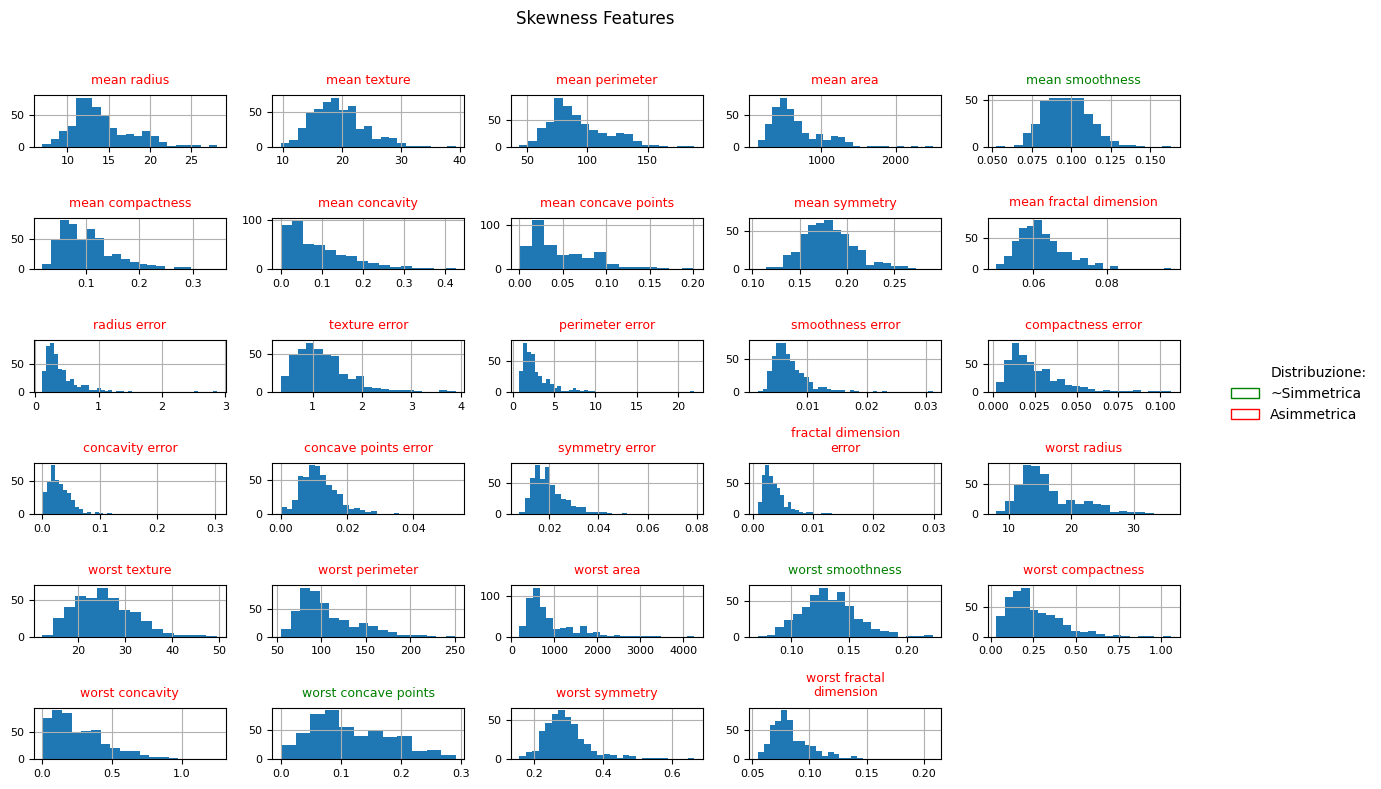

In [ ]:
plotta_distribuzione(X)

La maggior parte delle variabili presenta una distribuzione asimmetrica, tuttavia è necessario valutare questo aspetto dinamicamente durante l'esecuzione della pipeline, poiché fasi precedenti come l'imputazione o altre trasformazioni potrebbero modificarne la simmetria.

## Pipeline 1: Pre-processing per Record con Target = 1

In [ ]:
pipeline_1_cat = Pipeline(steps=[
    ("pipeline 1 cat pulizia dei valori mancanti",SimpleImputer(strategy='most_frequent')),
    ("pipeline 1 cat  one hot encoding",OneHotEncoder(sparse_output=False))
])

pipeline_1_num = Pipeline(steps=[
        (
            "pipeline 1 num sym pulizia dei valori mancanti selettiva",
            SelectiveTransformerBySkewness(
                transformer=SimpleImputer(strategy='mean'),
                apply_to='symmetric'
                )
        ),
        (
            "pipeline 1 num asym pulizia dei valori mancanti selettiva",
            SelectiveTransformerBySkewness(
                transformer=SimpleImputer(strategy='median'),
                apply_to='skewed'
                )
        ),
        (
            "pipeline 1 num asym simmetrizzazione selettiva",
            SelectiveTransformerBySkewness(
                transformer=PowerTransformer(
                    method='yeo-johnson',
                    standardize=False
                ),
                apply_to='skewed'
                )
        ),
        ("pipeline 1 num riscalatura",StandardScaler())

])

pipeline_1 = PipelineWithRowFilter(
    pipeline= ColumnTransformer(transformers=[
         ("pipeline 1 num",pipeline_1_num,make_column_selector(dtype_include=np.number)),
         ("pipeline 1 cat",pipeline_1_cat,make_column_selector(dtype_exclude=np.number))
         ]),
    target_value_to_drop=0
)

Pipeline 2: Pre-processing per Tutti i Record del Dataset

In [ ]:
pipeline_2_cat = Pipeline(steps=[
    ("pipeline 2 cat pulizia dei valori mancanti",SimpleImputer(strategy='most_frequent')),
    ("pipeline 2 cat ordinal encoding",OrdinalEncoder(categories=[['A', 'B', 'C']])),
])

pipeline_2_num = Pipeline(steps=[
        (
            "pipeline 2 num sym pulizia dei valori mancanti selettiva",
            SelectiveTransformerBySkewness(
                transformer=SimpleImputer(strategy='mean'),
                apply_to='symmetric'
                )
        ),
        (
            "pipeline 2 num asym pulizia dei valori mancanti selettiva",
            SelectiveTransformerBySkewness(
                transformer=SimpleImputer(strategy='median'),
                apply_to='skewed'
                )
        ),
        ("pipeline 2 num binning",KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform'))

])

pipeline_2 = Pipeline(steps=[
    (
        "pipeline 2 preprocessing", ColumnTransformer(transformers=[
            ("pipeline 2 num", pipeline_2_num,make_column_selector(dtype_include=np.number)),
            ("pipeline 2 cat", pipeline_2_cat,make_column_selector(dtype_exclude=np.number)),
            ])
    ),
    ("pipeline 2 selection", SelectKBest(f_classif,k = 5)),
])

## Pipeline 3: Pre-processing delle Variabili Numeriche

In [ ]:
pipeline_3_num = Pipeline(steps=[
        (
            "pipeline 3 num sym pulizia dei valori mancanti selettiva",
            SelectiveTransformerBySkewness(
                transformer=SimpleImputer(strategy='mean'),
                apply_to='symmetric'
                )
        ),
        (
            "pipeline 3 num asym pulizia dei valori mancanti selettiva",
            SelectiveTransformerBySkewness(
                transformer=SimpleImputer(strategy='median'),
                apply_to='skewed'
                )
        ),
        (
            "pipeline 3 num asym simmetrizzazione selettiva",
            SelectiveTransformerBySkewness(
                transformer=PowerTransformer(
                    method='yeo-johnson',
                    standardize=False
                ),
                apply_to='skewed'
                )
        ),
        ("pipeline 3 pca", PCA(n_components=0.85)),
        ("pipeline 3 normalizzazione",Normalizer()),
])

pipeline_3 = ColumnTransformer(transformers=[
            ("pipeline 3 num", pipeline_3_num,make_column_selector(dtype_include=np.number)),
            ])

## Pipeline Completa

Applicazione di FeatureUnion alla fine per crea un dataset max-feature.

In [ ]:
pipeline_completa = FeatureUnion([
    ("pipe1", pipeline_1),
    ("pipe2", pipeline_2),
    ("pipe3", pipeline_3),
])

pipeline_completa.fit(X,y)

FeatureUnion(transformer_list=[('pipe1',
                                PipelineWithRowFilter(pipeline=ColumnTransformer(transformers=[('pipeline '
                                                                                                '1 '
                                                                                                'num',
                                                                                                Pipeline(steps=[('pipeline '
                                                                                                                 '1 '
                                                                                                                 'num '
                                                                                                                 'sym '
                                                                                                                 'pulizia '
                                                                                                                 'dei '
                                                                                                                 'valori '
                                                                                                                 'mancanti '
                                                                                                                 'selettiva',
                                                                                                                 SelectiveTransformerBySkewness(apply_to='symmetric',
                                                                                                                                                transformer=SimpleImputer())),
                                                                                                                ('pipeline '
                                                                                                                 '1 '
                                                                                                                 'num '
                                                                                                                 'asym '
                                                                                                                 'pulizia '
                                                                                                                 'dei '
                                                                                                                 'valori '
                                                                                                                 'mancanti '
                                                                                                                 'sel...
                                                                                  SelectiveTransformerBySkewness(transformer=SimpleImputer(strategy='median'))),
                                                                                 ('pipeline '
                                                                                  '3 '
                                                                                  'num '
                                                                                  'asym '
                                                                                  'simmetrizzazione '
                                                                                  'selettiva',
                                                                                  SelectiveTransformerBySkewness(transformer=PowerTransformer(standardize=False))),
                                                                                 ('pipeline '
                                                                                  '3 '
                                             

## Salvataggio della Pipeline

In [ ]:
dump(pipeline_completa, "pipeline_completa.joblib")

['pipeline_completa.joblib']

## Test di utilizzo

In [ ]:
from joblib import load

pipeline_completa_test = load("pipeline_completa.joblib")

X_trasformati = pipeline_completa_test.transform(X)


In [ ]:
with pd.option_context('display.max_columns', None):
    display(X_trasformati)


,pipeline 1 num__mean radius,pipeline 1 num__mean texture,pipeline 1 num__mean perimeter,pipeline 1 num__mean area,pipeline 1 num__mean smoothness,pipeline 1 num__mean compactness,pipeline 1 num__mean concavity,pipeline 1 num__mean concave points,pipeline 1 num__mean symmetry,pipeline 1 num__mean fractal dimension,pipeline 1 num__radius error,pipeline 1 num__texture error,pipeline 1 num__perimeter error,pipeline 1 num__smoothness error,pipeline 1 num__compactness error,pipeline 1 num__concavity error,pipeline 1 num__concave points error,pipeline 1 num__symmetry error,pipeline 1 num__fractal dimension error,pipeline 1 num__worst radius,pipeline 1 num__worst texture,pipeline 1 num__worst perimeter,pipeline 1 num__worst area,pipeline 1 num__worst smoothness,pipeline 1 num__worst compactness,pipeline 1 num__worst concavity,pipeline 1 num__worst concave points,pipeline 1 num__worst symmetry,pipeline 1 num__worst fractal dimension,pipeline 1 cat__area error_A,pipeline 2 num__mean perimeter,pipeline 2 num__worst radius,pipeline 2 num__worst perimeter,pipeline 2 num__worst area,pipeline 2 num__worst concave points,pipeline 3 num__pca0,pipeline 3 num__pca1,pipeline 3 num__pca2,pipeline 3 num__pca3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12.0,4.0,9.0,18.0,-0.724017,0.551318,-0.136186,0.391537
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,10.0,8.0,12.0,-0.224768,0.952197,-0.073532,-0.193375
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,11.0,4.0,7.0,16.0,0.413650,0.881790,0.117181,-0.193928
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,1.0,17.0,0.900500,0.315228,-0.072906,0.290542
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,10.0,9.0,6.0,11.0,-0.841550,0.440349,0.212128,0.229973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,12.0,11.0,9.0,15.0,0.639412,0.718774,0.264643,-0.066930
565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,11.0,10.0,7.0,11.0,0.982911,0.081763,-0.054357,-0.155709
566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,7.0,7.0,4.0,9.0,0.982225,-0.029294,0.088521,-0.162912
567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,12.0,13.0,8.0,18.0,0.620098,0.537827,0.556563,-0.128290


In [ ]:
with pd.option_context('display.max_columns', None):
    display(X_trasformati.describe(include='all'))

,pipeline 1 num__mean radius,pipeline 1 num__mean texture,pipeline 1 num__mean perimeter,pipeline 1 num__mean area,pipeline 1 num__mean smoothness,pipeline 1 num__mean compactness,pipeline 1 num__mean concavity,pipeline 1 num__mean concave points,pipeline 1 num__mean symmetry,pipeline 1 num__mean fractal dimension,pipeline 1 num__radius error,pipeline 1 num__texture error,pipeline 1 num__perimeter error,pipeline 1 num__smoothness error,pipeline 1 num__compactness error,pipeline 1 num__concavity error,pipeline 1 num__concave points error,pipeline 1 num__symmetry error,pipeline 1 num__fractal dimension error,pipeline 1 num__worst radius,pipeline 1 num__worst texture,pipeline 1 num__worst perimeter,pipeline 1 num__worst area,pipeline 1 num__worst smoothness,pipeline 1 num__worst compactness,pipeline 1 num__worst concavity,pipeline 1 num__worst concave points,pipeline 1 num__worst symmetry,pipeline 1 num__worst fractal dimension,pipeline 1 cat__area error_A,pipeline 2 num__mean perimeter,pipeline 2 num__worst radius,pipeline 2 num__worst perimeter,pipeline 2 num__worst area,pipeline 2 num__worst concave points,pipeline 3 num__pca0,pipeline 3 num__pca1,pipeline 3 num__pca2,pipeline 3 num__pca3
count,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,3.570000e+02,357.0,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,9.454000e-17,-2.169444e-15,2.985474e-17,-6.966105e-17,2.244081e-15,4.080147e-16,8.458842e-17,-1.666889e-16,-3.050159e-15,1.384762e-14,7.413926e-16,-2.711805e-16,5.796795e-16,3.060111e-16,3.221824e-16,8.210053e-17,-1.791284e-16,1.363366e-15,4.727000e-17,-1.089698e-15,8.757389e-16,7.986142e-16,-1.194189e-16,2.189347e-16,5.722158e-16,-9.702789e-17,4.229421e-17,-4.105026e-17,-3.179529e-15,1.0,6.072056,5.217926,4.706503,2.880492,7.564148,0.012762,-0.022990,-0.010278,0.006252
std,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,1.001404e+00,0.0,3.163960,3.218284,3.101563,2.770529,4.262907,0.693657,0.506492,0.373421,0.351832
min,-3.063306e+00,-3.457967e+00,-3.048872e+00,-2.864237e+00,-4.967807e+00,-3.037007e+00,-2.214311e+00,-2.815875e+00,-3.842869e+00,-2.744914e+00,-2.548493e+00,-2.636470e+00,-3.251495e+00,-3.427293e+00,-2.694188e+00,-2.449147e+00,-2.847473e+00,-2.658282e+00,-2.654356e+00,-3.077316e+00,-3.523212e+00,-2.694747e+00,-2.387175e+00,-2.988580e+00,-2.572170e+00,-1.957164e+00,-2.282196e+00,-3.216042e+00,-3.197545e+00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.998149,-0.985424,-0.852485,-0.964797
25%,-5.092213e-01,-5.814722e-01,-5.614473e-01,-4.681995e-01,-3.858767e-01,-6.302181e-01,-4.971908e-01,-2.963316e-01,-5.308213e-01,-6.092828e-01,-5.689648e-01,-5.804515e-01,-4.529578e-01,-6.259838e-01,-6.247267e-01,-3.862399e-01,-5.857056e-01,-7.010438e-01,-5.839816e-01,-5.630249e-01,-5.341162e-01,-4.817195e-01,-6.285036e-01,-6.181876e-01,-6.342759e-01,-6.180795e-01,-5.426714e-01,-4.625662e-01,-5.470979e-01,1.0,4.000000,3.000000,3.000000,1.000000,4.000000,-0.704379,-0.419773,-0.240567,-0.214915
50%,0.000000e+00,1.594513e-02,0.000000e+00,0.000000e+00,-1.270144e-02,3.666384e-02,-5.302710e-03,2.142929e-03,-1.310150e-02,-1.677818e-02,-2.574146e-02,-1.334280e-02,1.672269e-03,-1.794111e-02,-7.277528e-02,-4.131129e-02,1.714503e-02,-2.550060e-02,-5.187909e-02,-9.969370e-16,1.285387e-02,0.000000e+00,0.000000e+00,0.000000e+00,3.104589e-02,5.843498e-02,0.0000

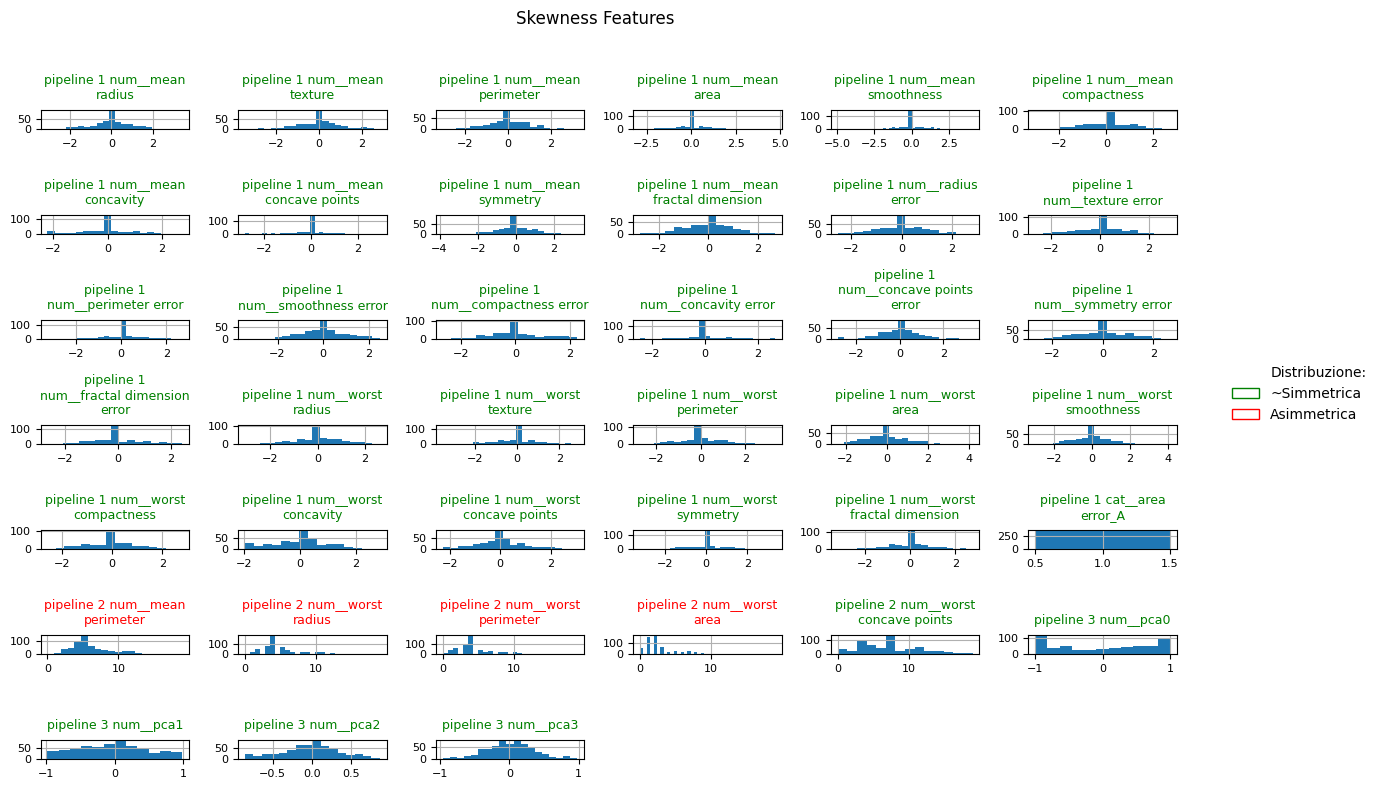

In [ ]:
with pd.option_context('display.max_columns', None):
    plotta_distribuzione(X_trasformati)

Il dato risulta conforme alle specifiche richeste.